In [1]:
import pandas as pd
import numpy as np
import seaborn as sns

In [3]:
df = pd.read_csv("/content/Housing.csv")

In [4]:
#first 10 rows
print(df.head(10))

      price   area  bedrooms  bathrooms  stories mainroad guestroom basement  \
0  13300000   7420         4          2        3      yes        no       no   
1  12250000   8960         4          4        4      yes        no       no   
2  12250000   9960         3          2        2      yes        no      yes   
3  12215000   7500         4          2        2      yes        no      yes   
4  11410000   7420         4          1        2      yes       yes      yes   
5  10850000   7500         3          3        1      yes        no      yes   
6  10150000   8580         4          3        4      yes        no       no   
7  10150000  16200         5          3        2      yes        no       no   
8   9870000   8100         4          1        2      yes       yes      yes   
9   9800000   5750         3          2        4      yes       yes       no   

  hotwaterheating airconditioning  parking prefarea furnishingstatus  
0              no             yes        2      

In [5]:
#shape
print("Rows, Columns:", df.shape)

Rows, Columns: (545, 13)


In [6]:
#columns names
print(df.columns)

Index(['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'mainroad',
       'guestroom', 'basement', 'hotwaterheating', 'airconditioning',
       'parking', 'prefarea', 'furnishingstatus'],
      dtype='object')


In [7]:
#missing values
print(df.isnull().sum())

price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64


In [8]:
#data cleaning
df.drop_duplicates(inplace=True)

In [9]:
df.isnull().sum()

,0
price,0
area,0
bedrooms,0
bathrooms,0
stories,0
mainroad,0
guestroom,0
basement,0
hotwaterheating,0
airconditioning,0


In [10]:
df.fillna(df.median(numeric_only=True), inplace=True)

In [11]:
df = pd.get_dummies(df, drop_first=True)

In [12]:
print(df.head())

      price  area  bedrooms  bathrooms  stories  parking  mainroad_yes  \
0  13300000  7420         4          2        3        2          True   
1  12250000  8960         4          4        4        3          True   
2  12250000  9960         3          2        2        2          True   
3  12215000  7500         4          2        2        3          True   
4  11410000  7420         4          1        2        2          True   

   guestroom_yes  basement_yes  hotwaterheating_yes  airconditioning_yes  \
0          False         False                False                 True   
1          False         False                False                 True   
2          False          True                False                False   
3          False          True                False                 True   
4           True          True                False                 True   

   prefarea_yes  furnishingstatus_semi-furnished  furnishingstatus_unfurnished  
0          True  

In [13]:
from sklearn.model_selection import train_test_split

X = df.drop("price", axis=1)
y = df["price"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [14]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

In [15]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


mae_lr = mean_absolute_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
r2_lr = r2_score(y_test, y_pred_lr)

print("Linear Regression")
print("MAE:", mae_lr)
print("RMSE:", rmse_lr)
print("R2:", r2_lr)

Linear Regression
MAE: 970043.4039201636
RMSE: 1324506.9600914386
R2: 0.6529242642153184


In [16]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

In [17]:
mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)

print("Random Forest")
print("MAE:", mae_rf)
print("RMSE:", rmse_rf)
print("R2:", r2_rf)

Random Forest
MAE: 1021546.0353211008
RMSE: 1400565.9728553821
R2: 0.611918531405699


<h3>Charts</h3>

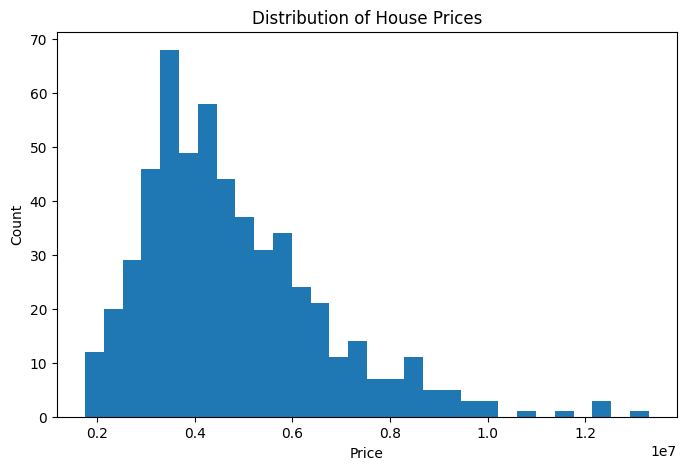

In [18]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.hist(df["price"], bins=30)
plt.title("Distribution of House Prices")
plt.xlabel("Price")
plt.ylabel("Count")
plt.savefig("Histogram.png")
plt.show()

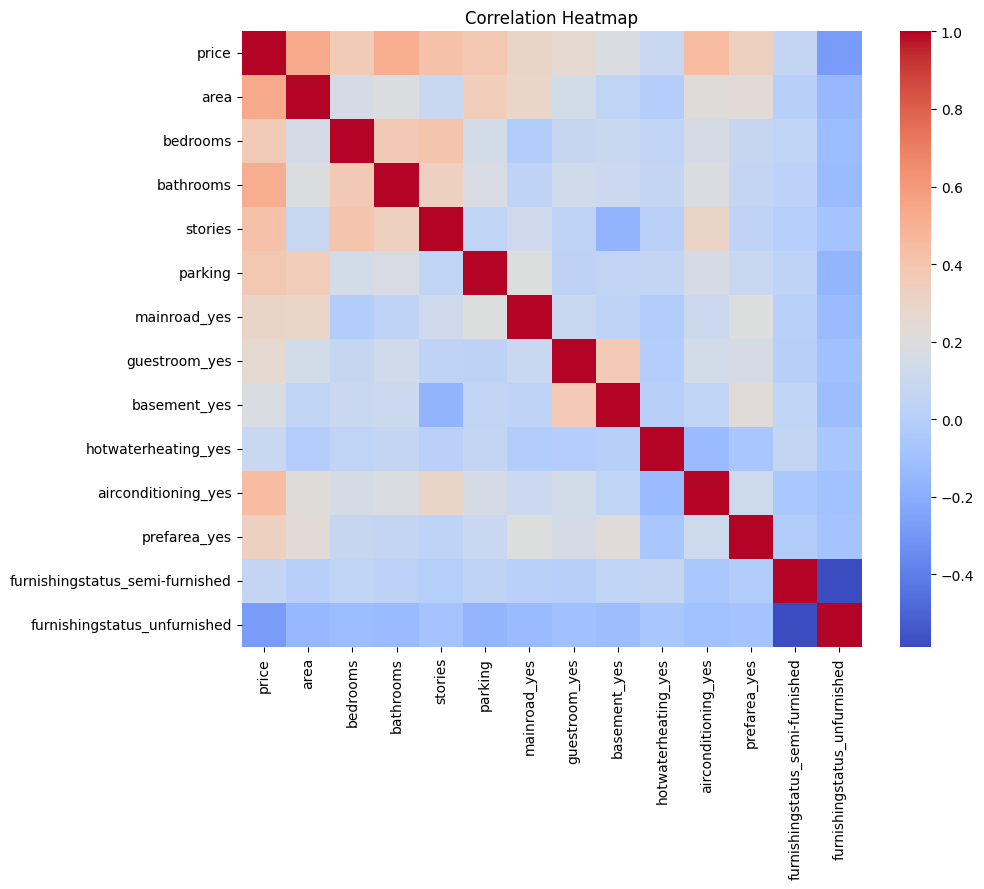

In [19]:
import seaborn as sns

plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), cmap="coolwarm")

plt.title("Correlation Heatmap")
plt.savefig("Correlation_heatmap.png")
plt.show()

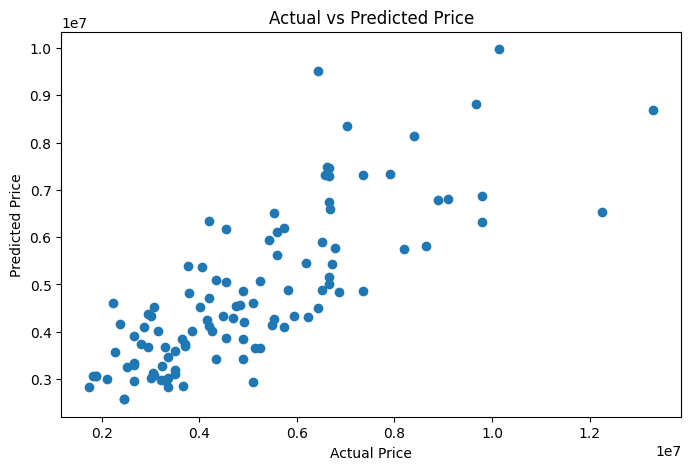

In [20]:
plt.figure(figsize=(8,5))
plt.scatter(y_test, y_pred_rf)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Price")
plt.savefig("Scatter_Plot.png")
plt.show()

In [21]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

print(importance.head(10))

                         Feature  Importance
0                           area    0.468430
2                      bathrooms    0.151483
9            airconditioning_yes    0.062672
4                        parking    0.057455
3                        stories    0.057133
1                       bedrooms    0.048413
12  furnishingstatus_unfurnished    0.035011
7                   basement_yes    0.030823
10                  prefarea_yes    0.030689
8            hotwaterheating_yes    0.017226


<h3>Summary</h3>

The analysis showed that house area was the most important factor influencing price, followed by the number of bathrooms, air conditioning, parking availability, stories, and bedrooms.

The Linear Regression model performed better than the Random Forest model, achieving an R² score of 0.653, which means it was able to explain about 65% of the variation in house prices.

In simple terms, the model was reasonably accurate and could predict house prices fairly well, although some prediction error remained.

One surprising finding was that the simpler Linear Regression model outperformed the more complex Random Forest model. This suggests that the relationship between the housing features and price is relatively straightforward. Based on these findings, real estate businesses should focus on property size and key amenities when estimating house values and setting prices.
